Emulating halo exchange

In [91]:
include("utils.jl");
import WAVI.Fields: GridField, InitialConditions
import WAVI.Models: get_bed_elevation

In [110]:
# Number of processes in x and y directions
px, py = 3, 1

# Number of halo cells on each side of the subgrid
halo::Integer = 2

# Total number of processes
global_size::Integer = px * py

3

In [93]:
"""
Emulate a single rank decomposition

    Args:
        current_rank (int): The rank to emulate
"""
function emulate_rank(current_rank::Integer)::GridField
    grid = MISMIP_PLUS_GRID()

    coords, top, right, bottom, left = emulate_mpi_creation(global_size, px, py, current_rank)
    spec = MPISpec(top, right, bottom, left, halo, grid.nx, grid.ny, px, py, coords, global_size, current_rank)

    th, rh, bh, lh = get_halos(spec)
    nx_local, ny_local = get_size(spec)
    x_start, x_end, y_start, y_end = get_bounds(spec)

    x0_local = grid.x0 + (x_start-1) * grid.dx
    y0_local = grid.y0 + (y_start-1) * grid.dy
    
    @info "[$(current_rank+1)/$(global_size)] - proc $(coords[1]),$(coords[2]) - grid $(nx_local)x$(ny_local)"
    @info "[$(current_rank+1)/$(global_size)] - X [$(x_start):$(x_end)] - Y [$(y_start):$(y_end)] - Centroid $(x0_local),$(y0_local) "


    initial_conditions = InitialConditions()
    params::Params = Params()
    solver_params::SolverParams = SolverParams()
    bed_elevation = WAVI.mismip_plus_bed
    u_grid_size, v_grid_size = (grid.nx+1, grid.ny), (grid.nx, grid.ny+1)
    
    conditions = InitialConditions(
        initial_thickness = size(initial_conditions.initial_thickness) == size(grid)[1:2] ? 
            initial_conditions.initial_thickness[x_start:x_end, y_start:y_end] : initial_conditions.initial_thickness,
        initial_grounded_fraction = size(initial_conditions.initial_grounded_fraction) == size(grid)[1:2] ? 
            initial_conditions.initial_grounded_fraction[x_start:x_end, y_start:y_end] : initial_conditions.initial_grounded_fraction,
        initial_u_veloc = size(initial_conditions.initial_u_veloc) == u_grid_size ? 
            initial_conditions.initial_u_veloc[x_start:x_end+1, y_start:y_end] : initial_conditions.initial_u_veloc,
        initial_v_veloc = size(initial_conditions.initial_v_veloc) == v_grid_size ? 
            initial_conditions.initial_v_veloc[x_start:x_end, y_start:y_end+1] : initial_conditions.initial_v_veloc,
        initial_viscosity = size(initial_conditions.initial_viscosity) == size(grid) ? 
            initial_conditions.initial_viscosity[x_start:x_end, y_start:y_end, :] : initial_conditions.initial_viscosity,
        initial_temperature = size(initial_conditions.initial_temperature) == size(grid) ? 
            initial_conditions.initial_temperature[x_start:x_end, y_start:y_end, :] : initial_conditions.initial_temperature,
        initial_damage = size(initial_conditions.initial_damage) == size(grid) ? 
            initial_conditions.initial_damage[x_start:x_end, y_start:y_end, :] : initial_conditions.initial_damage
    )


    # dt cannot be copied via the external constructor so we create the structure directly
    local_params = Params(
        params.dt,
        params.g, 
        params.density_ice, 
        params.density_ocean, 
        params.gas_const,
        params.sec_per_year, 
        params.default_thickness, 
        params.default_viscosity,
        params.default_temperature,
        params.default_damage,
        size(params.accumulation_rate) == size(grid)[1:2] ? 
            params.accumulation_rate[x_start:x_end, y_start:y_end] : params.accumulation_rate,
        params.glen_a_activation_energy,
        size(params.glen_a_ref) == size(grid)[1:2] ? 
            params.glen_a_ref[x_start:x_end, y_start:y_end] : params.glen_a_ref,
        params.glen_temperature_ref,
        params.glen_n,
        params.glen_reg_strain_rate,
        size(params.weertman_c) == size(grid)[1:2] ? 
            params.weertman_c[x_start:x_end, y_start:y_end] : params.weertman_c,
        params.weertman_m,
        params.weertman_reg_speed,
        params.sea_level_wrt_geoid,
        params.minimum_thickness,
        params.evolveShelves,
        params.smallHAF
    )

    u_isfixed = grid.u_isfixed[x_start:x_end+1, y_start:y_end]
    v_isfixed = grid.v_isfixed[x_start:x_end, y_start:y_end+1]
    
    # Set halos as fixed velocities
    (spec.left==-1) || (u_isfixed[1,:] .= true; v_isfixed[1,:] .= true)
    (spec.right==-1) || (u_isfixed[end,:] .= true; v_isfixed[end,:] .= true)
    (spec.top==-1) || (u_isfixed[:,1] .= true; v_isfixed[:,1] .= true)
    (spec.bottom==-1) || (u_isfixed[:,end] .= true; v_isfixed[:,end] .= true)

    local_grid = Grid(
        nx = nx_local,
        ny = ny_local,
        nσ = grid.nσ,
        dx = grid.dx,
        dy = grid.dy,
        x0 = x0_local,
        y0 = y0_local,
        h_mask = grid.h_mask[x_start:x_end, y_start:y_end],
        h_isfixed = grid.h_isfixed[x_start:x_end, y_start:y_end],
        u_iszero = grid.u_iszero[x_start:x_end+1, y_start:y_end],
        v_iszero = grid.v_iszero[x_start:x_end, y_start:y_end+1],
        u_isfixed = u_isfixed,
        v_isfixed = v_isfixed,
        quadrature_weights = grid.quadrature_weights,
        σ = grid.σ,
        basin_ID = grid.basin_ID[x_start:x_end, y_start:y_end])

    if typeof(bed_elevation) <: AbstractArray
        bed_array = bed_elevation[x_start:x_end, y_start:y_end]
    else
        bed_array = get_bed_elevation(bed_elevation, local_grid)
    end
    
    fields = GridField(local_grid, bed_array; initial_conditions=conditions, params=local_params, solver_params)

    return fields
end

emulate_rank

In [94]:
# for rank in 0:global_size-1
#     emulate_rank(rank)
# end

# FieldError: type GridField has no field `u`, available fields: `gh`, `gu`, `gv`, `gc`, `g3d`, `wu`, `wv`
fields = emulate_rank(0);

┌ Info: [1/3] - proc 0,0 - grid 27x10
└ @ Main /home/bryald/git/WAVI/WAVI.jl/dev/notebooks/mpi/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W1sZmlsZQ==.jl:20
┌ Info: [1/3] - X [1:27] - Y [1:10] - Centroid 0.0,-40000.0 
└ @ Main /home/bryald/git/WAVI/WAVI.jl/dev/notebooks/mpi/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W1sZmlsZQ==.jl:21
┌ Info: Setting up initial conditions based on params
└ @ WAVI.Fields /home/bryald/git/WAVI/WAVI.jl/src/Fields/utils.jl:56


In [95]:
fieldnames(typeof(fields))

(:gh, :gu, :gv, :gc, :g3d, :wu, :wv)

In [96]:
propertynames(fields.gu)

(:nxu, :nyu, :mask, :mask_inner, :u_isfixed, :n, :ni, :crop, :samp, :samp_inner, :spread, :spread_inner, :cent, :centᵀ, :∂x, :∂xᵀ, :∂y, :∂yᵀ, :levels, :dwt, :s, :h, :grounded_fraction, :βeff, :dnegβeff, :u, :residual)

In [97]:
typeof(fields.gu.u)

Matrix{Float64} (alias for Array{Float64, 2})

In [98]:
using Parameters
@unpack gh, gu, gv = fields;

In [99]:
current_rank = 0
for field_sym in [(gu, :u, (1, 0)), (gv, :v, (0, 1))]
    field, field_name, shift = field_sym
    coords, top, right, bottom, left = emulate_mpi_creation(global_size, px, py, current_rank)
    @info "[$(rank+1)/$(global_size)] - proc $(coords[1]),$(coords[2]) - $(shift) - $(field_name)"
    # exchange_halo!(field, spec)
end

┌ Info: [1/3] - proc 0,0 - (1, 0) - u
└ @ Main /home/bryald/git/WAVI/WAVI.jl/dev/notebooks/mpi/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X16sZmlsZQ==.jl:5
┌ Info: [1/3] - proc 0,0 - (0, 1) - v
└ @ Main /home/bryald/git/WAVI/WAVI.jl/dev/notebooks/mpi/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X16sZmlsZQ==.jl:5


In [100]:
size(gu.u)

(28, 10)

In [102]:
size(gu.u)

(28, 10)

Current rank: 0
0, 2, 0, 0
29, 10
1, 29, 1, 10


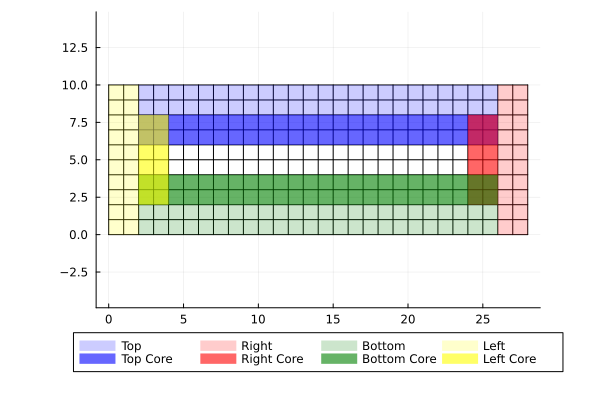

In [ ]:
using Plots
gr()

function colour_halos(p, cells, Ny; fillcolor=:blue, fillalpha=0.4, label=false)
    # Since plotting origin is bottom left, adjust indices
    # so that origin is top left just like indexing of arrays
    for (idx, (i, j)) in enumerate(cells)
        y0 = Ny - j
        y1 = Ny - j + 1
        plot!(p,
            [i-1, i, i, i-1],
            [y0, y0, y1, y1],
            seriestype=:shape,
            fillcolor=fillcolor,
            fillalpha=fillalpha,
            linecolor=:transparent,
            label = idx == 1 ? label : false,
        )
    end
end

function plot_grid(gu; current_rank=nothing)
    grid = MISMIP_PLUS_GRID()

    if current_rank != nothing
        println("Current rank: $current_rank")
        coords, top, right, bottom, left = emulate_mpi_creation(global_size, px, py, current_rank)
        spec = MPISpec(top, right, bottom, left, halo, grid.nx, grid.ny, px, py, coords, global_size, current_rank)

        th, rh, bh, lh = get_halos(spec)
        nx_local, ny_local = get_size(spec)
        x_start, x_end, y_start, y_end = get_bounds(spec)
        println(th, ", ", rh, ", ", bh, ", ", lh)
        println(nx_local, ", ", ny_local)
        println(x_start, ", ", x_end, ", ", y_start, ", ", y_end)
    end

    Nx, Ny = size(gu.u)

    p = plot(; aspect_ratio=:equal, legend=false)

    # Plot core grid
    for x in 0:Nx
        plot!([x, x], [0, Ny], color=:black, lw=1, label=false)
    end
    for y in 0:Ny
        plot!([0, Nx], [y, y], color=:black, lw=1, label=false)
    end

    th = 2
    rh = 2
    lh = 2
    bh = 2
    end_x = size(gu.u)[1] - rh
    end_y = size(gu.u)[2] - bh

    # Colour halo cells
    fill_alpha = 0.2
    top_cells = [(i, j) for j in 1:th for i in 1+lh:end_x]
    right_cells = [(i, j) for j in 1:end_y + bh for i in end_x+1:end_x+rh]
    bottom_cells = [(i, j) for j in end_y+1:end_y+rh for i in 1+lh:end_x]
    left_cells = [(i, j) for j in 1:end_y + bh for i in 1:lh]

    colour_halos(p, top_cells, Ny; fillcolor=:blue, fillalpha=fill_alpha, label="Top")
    colour_halos(p, right_cells, Ny; fillcolor=:red, fillalpha=fill_alpha, label="Right")
    colour_halos(p, bottom_cells, Ny; fillcolor=:green, fillalpha=fill_alpha, label="Bottom")
    colour_halos(p, left_cells, Ny; fillcolor=:yellow, fillalpha=fill_alpha, label="Left")

    # Colour core cells
    fill_alpha = 0.6
    top_cells = [(i, j) for j in th+1:2*th for i in 1+lh:end_x]
    right_cells = [(i, j) for j in th+1:end_y-bh + bh for i in end_x+1-rh:end_x]
    bottom_cells = [(i, j) for j in end_y+1-bh:end_y for i in 1+lh:end_x]
    left_cells = [(i, j) for j in th+1:end_y for i in lh+1:2*lh]

    colour_halos(p, top_cells, Ny; fillcolor=:blue, fillalpha=fill_alpha, label="Top Core")
    colour_halos(p, right_cells, Ny; fillcolor=:red, fillalpha=fill_alpha, label="Right Core")
    colour_halos(p, bottom_cells, Ny; fillcolor=:green, fillalpha=fill_alpha, label="Bottom Core")
    colour_halos(p, left_cells, Ny; fillcolor=:yellow, fillalpha=fill_alpha, label="Left Core")

    num_labels = sum([1 for halo in [th, rh, bh, lh] if halo > 0])
    plot!(legend=:outerbottom, legendcolumns=num_labels)

    display(p)
end

plot_grid(gu; current_rank=0)